In [33]:
import subprocess
import sys
import os

def install_if_missing(package):
    """Check if package is installed, if not install it."""
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Install packages
install_if_missing('pandas')
install_if_missing('numpy')
install_if_missing('matplotlib')
install_if_missing('pylab')
install_if_missing('IPython')

# Now import them
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

import time
import math

import pylab as py
from IPython.display import HTML

In [17]:
class Body:
    def __init__(self, mass, position, velocity):
        self.mass = mass
        self.position = position
        self.velocity = velocity

    def copy(self):
        return Body(self.mass, self.position[:], self.velocity[:])

In [18]:
#parameters
G = 6.673e-11 #N m^2 / kg^2
M_Earth  = 6.0e24
M_oculus = 500 #kg
M_lux = 500 #kg

R_earth = 6371e3 #m
R_orbit = 100e6 #m

d_spacecraft = 140 #m
orientation_polar = 90 * math.pi / 180 # radians
orientation_azimuthal = 0 * math.pi / 180 # radians

v_spacecraft_0 = math.sqrt(G*M_Earth/R_orbit) # m/s
T_orbit = 2*math.pi*R_orbit/v_spacecraft_0
T_orbit_hours = T_orbit / 3600
T_orbit_days = T_orbit_hours / 24

orbit_inclination = 51.6 * math.pi / 180 # radians

N_steps = 50000
dt = T_orbit / N_steps
t = np.linspace(0, T_orbit, N_steps)

In [19]:
r_oculus_0 = np.array([R_orbit*np.cos(orbit_inclination), 0, R_orbit*np.sin(orbit_inclination)])
v_oculus_0 = np.array([0, v_spacecraft_0, 0])

r_lux_0 = r_oculus_0 + np.array([d_spacecraft*np.cos(orientation_polar)*math.cos(orientation_azimuthal), d_spacecraft*np.cos(orientation_polar)*math.sin(orientation_azimuthal), d_spacecraft*np.sin(orientation_polar)])
v_lux_0 = v_oculus_0 + np.array([0, 0, 0]) # Assuming same velocity for simplicity

orbital_normal_vector = np.array([-np.sin(orbit_inclination), 0, np.cos(orbit_inclination)]) # Assuming normal vector along z-axis for simplicity

In [20]:
def compute_gravitational_acceleration(position):
    r = np.linalg.norm(position)
    return -G * M_Earth / r**3 * position

def update_position_velocity(body, dt):
    # Compute acceleration
    acceleration = compute_gravitational_acceleration(body.position)
    
    # Update velocity (using simple Euler method)
    body.velocity += acceleration * dt
    
    # Update position
    body.position += body.velocity * dt

In [34]:
def make_initial_conditions(polar_angle, inclination):
    r_oculus_0 = np.array([
        R_orbit * np.cos(inclination),
        0.0,
        R_orbit * np.sin(inclination)
    ])

    v_oculus_0 = np.array([
        0.0,
        v_spacecraft_0,
        0.0
    ])

    r_lux_0 = r_oculus_0 + np.array([
        d_spacecraft * np.cos(polar_angle) * np.cos(orientation_azimuthal),
        d_spacecraft * np.cos(polar_angle) * np.sin(orientation_azimuthal),
        d_spacecraft * np.sin(polar_angle)
    ])

    v_lux_0 = v_oculus_0.copy()

    orbital_normal_vector = np.array([
        -np.sin(inclination),
        0.0,
        np.cos(inclination)
    ])

    return r_oculus_0, v_oculus_0, r_lux_0, v_lux_0, orbital_normal_vector


In [ ]:
class Simulation:
    def __init__(self, body1, body2, dt, n_steps, gravity_func):
        self.body1 = body1
        self.body2 = body2
        self.dt = dt
        self.n_steps = n_steps
        self.gravity_func = gravity_func

        self.relative_offset = self.body2.position.copy() - self.body1.position.copy()

        self.r1 = np.zeros((n_steps, 3))
        self.v1 = np.zeros((n_steps, 3))
        self.r2 = np.zeros((n_steps, 3))
        self.v2 = np.zeros((n_steps, 3))

        self.a1 = np.zeros((n_steps, 3))
        self.a2_total = np.zeros((n_steps, 3))
        self.a2_grav = np.zeros((n_steps, 3))
        self.a2_constraint = np.zeros((n_steps, 3))

        self.f2_constraint = np.zeros((n_steps, 3))
        self.total_impulse = 0.0
        self.has_run = False

        self._store_step(0)

    def _store_step(self, i):
        self.r1[i] = self.body1.position
        self.v1[i] = self.body1.velocity
        self.r2[i] = self.body2.position
        self.v2[i] = self.body2.velocity

    def _rk4_step_with_constraint(self):
        dt = self.dt
        d0 = self.relative_offset

        r1_0 = self.body1.position.copy()
        v1_0 = self.body1.velocity.copy()

        def acc(r_vec):
            return self.gravity_func(r_vec)

        # ---------- stage 1 ----------
        r1_s1 = r1_0
        v1_s1 = v1_0
        a1_s1 = acc(r1_s1)

        r2_s1 = r1_s1 + d0
        v2_s1 = v1_s1.copy()
        a2_grav_s1 = acc(r2_s1)
        a2_req_s1 = a1_s1.copy()
        a2_con_s1 = a2_req_s1 - a2_grav_s1

        k1_r = v1_s1
        k1_v = a1_s1

        # ---------- stage 2 ----------
        r1_s2 = r1_0 + 0.5 * dt * k1_r
        v1_s2 = v1_0 + 0.5 * dt * k1_v
        a1_s2 = acc(r1_s2)

        r2_s2 = r1_s2 + d0
        v2_s2 = v1_s2.copy()
        a2_grav_s2 = acc(r2_s2)
        a2_req_s2 = a1_s2.copy()
        a2_con_s2 = a2_req_s2 - a2_grav_s2

        k2_r = v1_s2
        k2_v = a1_s2

        # ---------- stage 3 ----------
        r1_s3 = r1_0 + 0.5 * dt * k2_r
        v1_s3 = v1_0 + 0.5 * dt * k2_v
        a1_s3 = acc(r1_s3)

        r2_s3 = r1_s3 + d0
        v2_s3 = v1_s3.copy()
        a2_grav_s3 = acc(r2_s3)
        a2_req_s3 = a1_s3.copy()
        a2_con_s3 = a2_req_s3 - a2_grav_s3

        k3_r = v1_s3
        k3_v = a1_s3

        # ---------- stage 4 ----------
        r1_s4 = r1_0 + dt * k3_r
        v1_s4 = v1_0 + dt * k3_v
        a1_s4 = acc(r1_s4)

        r2_s4 = r1_s4 + d0
        v2_s4 = v1_s4.copy()
        a2_grav_s4 = acc(r2_s4)
        a2_req_s4 = a1_s4.copy()
        a2_con_s4 = a2_req_s4 - a2_grav_s4

        k4_r = v1_s4
        k4_v = a1_s4

        # ---------- final RK4 update ----------
        r1_new = r1_0 + dt * (k1_r + 2*k2_r + 2*k3_r + k4_r) / 6.0
        v1_new = v1_0 + dt * (k1_v + 2*k2_v + 2*k3_v + k4_v) / 6.0

        a1_rk4 = (a1_s1 + 2*a1_s2 + 2*a1_s3 + a1_s4) / 6.0
        a2_total_rk4 = (a2_req_s1 + 2*a2_req_s2 + 2*a2_req_s3 + a2_req_s4) / 6.0
        a2_grav_rk4 = (a2_grav_s1 + 2*a2_grav_s2 + 2*a2_grav_s3 + a2_grav_s4) / 6.0
        a2_con_rk4 = (a2_con_s1 + 2*a2_con_s2 + 2*a2_con_s3 + a2_con_s4) / 6.0

        r2_new = r1_new + d0
        v2_new = v1_new.copy()

        self.body1.position = r1_new
        self.body1.velocity = v1_new
        self.body2.position = r2_new
        self.body2.velocity = v2_new

        return a1_rk4, a2_total_rk4, a2_grav_rk4, a2_con_rk4

    def run(self, trim_start=0):
        for i in range(1, self.n_steps):
            a1_rk4, a2_total_rk4, a2_grav_rk4, a2_con_rk4 = self._rk4_step_with_constraint()
            self._store_step(i)

            self.a1[i] = a1_rk4
            self.a2_total[i] = a2_total_rk4
            self.a2_grav[i] = a2_grav_rk4
            self.a2_constraint[i] = a2_con_rk4

            self.f2_constraint[i] = self.body2.mass * a2_con_rk4
            self.total_impulse += np.linalg.norm(self.f2_constraint[i]) * self.dt

        if trim_start > 0:
            self.r1 = self.r1[trim_start:]
            self.v1 = self.v1[trim_start:]
            self.r2 = self.r2[trim_start:]
            self.v2 = self.v2[trim_start:]
            self.a1 = self.a1[trim_start:]
            self.a2_total = self.a2_total[trim_start:]
            self.a2_grav = self.a2_grav[trim_start:]
            self.a2_constraint = self.a2_constraint[trim_start:]
            self.f2_constraint = self.f2_constraint[trim_start:]

        self.has_run = True

    def plot_trajectories(self):
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot(self.r1[:, 0], self.r1[:, 1], self.r1[:, 2], label="Oculus")
        ax.plot(self.r2[:, 0], self.r2[:, 1], self.r2[:, 2], label="Lux")
        ax.scatter(0, 0, 0, color="gold", s=100, label="Earth")

        ax.set_xlabel("X Position (m)")
        ax.set_ylabel("Y Position (m)")
        ax.set_zlabel("Z Position (m)")
        ax.set_title("3D Trajectories")
        ax.legend()
        plt.show()

    def plot_constraint_force(self):
        plt.figure(figsize=(10, 5))
        plt.plot(np.linalg.norm(self.f2_constraint, axis=1))
        plt.xlabel("Time Step")
        plt.ylabel("Constraint Force (N)")
        plt.title("Constraint Force Magnitude on Body 2")
        plt.grid(True)
        plt.show()

    def print_total_impulse(self):
        print(f"Total Impulse Exerted on Body 2: {self.total_impulse:.2e} N·s")

    def save_to_csv(self, filename):
        data = {
            "time": np.arange(len(self.r1)) * self.dt,
            "r1_x": self.r1[:, 0],
            "r1_y": self.r1[:, 1],
            "r1_z": self.r1[:, 2],
            "v1_x": self.v1[:, 0],
            "v1_y": self.v1[:, 1],
            "v1_z": self.v1[:, 2],
            "r2_x": self.r2[:, 0],
            "r2_y": self.r2[:, 1],
            "r2_z": self.r2[:, 2],
            "v2_x": self.v2[:, 0],
            "v2_y": self.v2[:, 1],
            "v2_z": self.v2[:, 2],
            "a1_x": self.a1[:, 0],
            "a1_y": self.a1[:, 1],
            "a1_z": self.a1[:, 2],
            "a2_total_x": self.a2_total[:, 0],
            "a2_total_y": self.a2_total[:, 1],
            "a2_total_z": self.a2_total[:, 2],
            "a2_grav_x": self.a2_grav[:, 0],
            "a2_grav_y": self.a2_grav[:, 1],
            "a2_grav_z": self.a2_grav[:, 2],
            "a2_constraint_x": self.a2_constraint[:, 0],
            "a2_constraint_y": self.a2_constraint[:, 1],
            "a2_constraint_z": self.a2_constraint[:, 2],
            "f2_constraint_x": self.f2_constraint[:, 0],
            "f2_constraint_y": self.f2_constraint[:, 1],
            "f2_constraint_z": self.f2_constraint[:, 2],
        }
        df = pd.DataFrame(data)
        df.to_csv(filename, index=False)


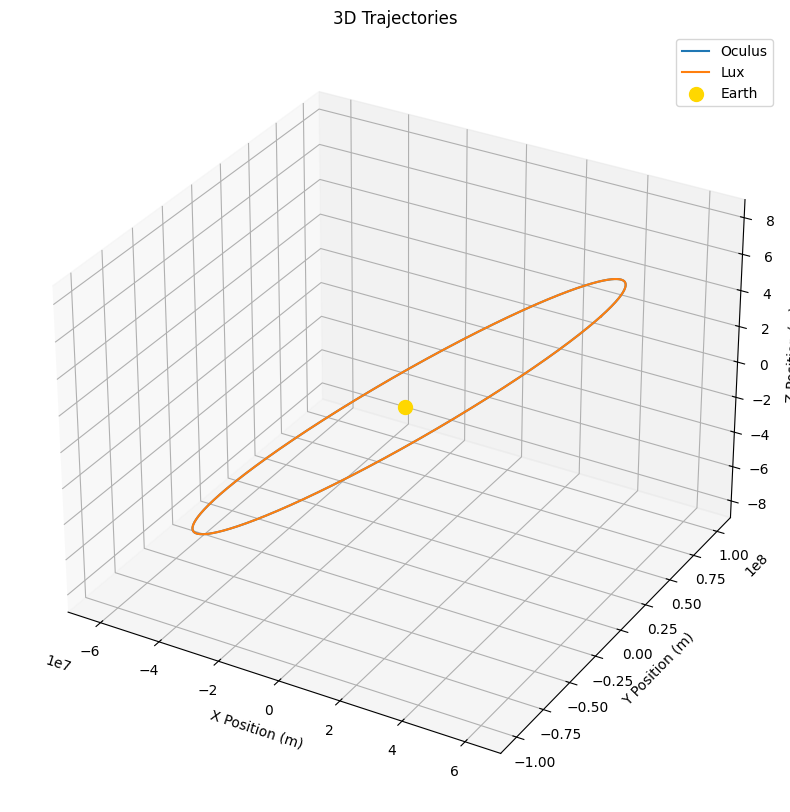

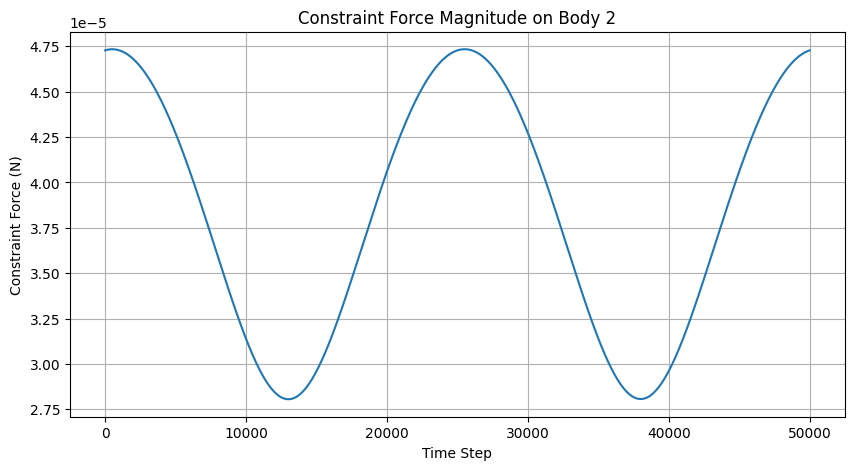

Total Impulse Exerted on Body 2: 1.21e+01 N·s


In [32]:
test_simulation = Simulation(Body(M_oculus, r_oculus_0, v_oculus_0), Body(M_lux, r_lux_0, v_lux_0), dt, N_steps, compute_gravitational_acceleration)
test_simulation.run(4)
test_simulation.plot_trajectories()
test_simulation.plot_constraint_force()
test_simulation.print_total_impulse()
test_simulation.save_to_csv("simulation_results_test.csv")

In [38]:
polar_angles = np.linspace(-90, 90, 20) * math.pi / 180
orbit_inclinations = np.linspace(0, 90, 20) * math.pi / 180

output_dir = "simulation_runs"
os.makedirs(output_dir, exist_ok=True)

total_impulse_map = np.zeros((len(polar_angles), len(orbit_inclinations)))

for i, polar_angle in enumerate(polar_angles):
    for j, inclination in enumerate(orbit_inclinations):
        # Build fresh initial conditions here
        r1_0, v1_0, r2_0, v2_0, orbital_normal_vector = make_initial_conditions(polar_angle, inclination)

        body1 = Body(M_oculus, r1_0.copy(), v1_0.copy())
        body2 = Body(M_lux, r2_0.copy(), v2_0.copy())

        sim = Simulation(body1, body2, dt, N_steps, compute_gravitational_acceleration)
        sim.run(trim_start=4)

        filename = (
            f"run_pa_{np.degrees(polar_angle):+.1f}_"
            f"inc_{np.degrees(inclination):.1f}.csv"
        )
        filepath = os.path.join(output_dir, filename)
        sim.save_to_csv(filepath)

        total_impulse_map[i, j] = sim.total_impulse

        del sim  # Free memory immediately after saving results

# Save the summary array separately
np.save(os.path.join(output_dir, "total_impulse_map.npy"), total_impulse_map)
np.savetxt(
    os.path.join(output_dir, "total_impulse_map.csv"),
    total_impulse_map,
    delimiter=","
)

# Optional: save the actual parameter values too
np.savetxt(
    os.path.join(output_dir, "polar_angles_deg.csv"),
    np.degrees(polar_angles),
    delimiter=","
)
np.savetxt(
    os.path.join(output_dir, "orbit_inclinations_deg.csv"),
    np.degrees(orbit_inclinations),
    delimiter=","
)


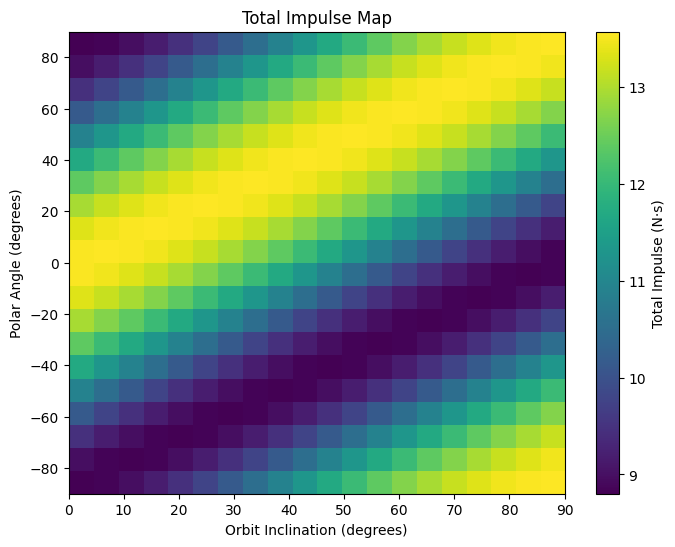

In [39]:
plt.figure(figsize=(8, 6))
plt.imshow(total_impulse_map, extent=[0, 90, -90, 90], aspect="auto", origin="lower")
plt.colorbar(label="Total Impulse (N·s)")
plt.xlabel("Orbit Inclination (degrees)")
plt.ylabel("Polar Angle (degrees)")
plt.title("Total Impulse Map")
plt.show()